In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import time
import itertools

In [2]:
%matplotlib inline

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family']='Malgun Gothic'

In [3]:
df = pd.read_csv("../../DB/최종_모델학습용.csv", encoding="cp949")
print(f"데이터프레임 shape: {df.shape}")
df.head(3)

데이터프레임 shape: (590, 25)


,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,...,0.386303,0.365099,0.144122,0.074742,0.029734,0,0,0,1,0
1,강원_고성군,2467.3,강원,고성군,15431,27305,0.6840,0.2650,0.0116,0.0114,...,0.415669,0.353801,0.134385,0.071040,0.025105,0,0,0,0,1
2,강원_동해시,4818.0,강원,동해시,41141,90522,0.2689,0.6416,0.0426,0.0296,...,0.291131,0.333738,0.198045,0.133457,0.043630,1,0,0,0,0


In [4]:
year_columns = ['연도_2019', '연도_2020', '연도_2021', '연도_2022', '연도_2023']

# 연도 변수 생성
df['연도'] = df[year_columns].idxmax(axis=1).str.extract('(\d+)').astype(int)

# 기존 더미 변수 삭제
df = df.drop(columns=year_columns + ['log_혼합배출_후_재활용량'])
df.head(1)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,비주거용주택비율,총전입,총전출,순이동,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,0.0281,3269,2968,301,0.386303,0.365099,0.144122,0.074742,0.029734,2022


In [5]:
df.shape

(590, 20)

### 총인구수 로그변환

In [67]:
df.columns

Index(['행정구역', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입', '총전출', '순이동',
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율', '연도', 'ln총인구수',
       'ln총전입'],
      dtype='object')

In [14]:
df['ln총인구수'] = np.log(df['총인구수'])

In [43]:
df['ln총전입'] = np.log(df['총전입'])

In [68]:
df['ln총전출'] = np.log(df['총전출'])

# data split

In [70]:
# 부산 2023
busan_2023 = df[(df['시도'] == '부산')&(df['연도'] == 2023)].reset_index(drop=True)
busan_2023.head(2)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,순이동,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도,ln총인구수,ln총전입,ln총전출
0,부산_강서구,11805.7,부산,강서구,62238,142396,0.1790,0.7894,0.0068,0.0159,...,-1203,0.30575,0.267591,0.207005,0.176826,0.042828,2023,11.866367,9.647756,9.722565
1,부산_금정구,24013.1,부산,금정구,105906,215590,0.1773,0.5656,0.0347,0.2080,...,-4379,0.40046,0.295430,0.174782,0.104118,0.025210,2023,12.281134,9.934841,10.127271


In [71]:
busan_2023.shape

(16, 23)

In [72]:
# 부산 2023 을 뺀 데이터 프레임
df_1 = df[~((df['시도'] == '부산')&(df['연도'] == 2023))].reset_index(drop=True)
df_1.head(2)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,순이동,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도,ln총인구수,ln총전입,ln총전출
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,...,301,0.386303,0.365099,0.144122,0.074742,0.029734,2022,10.213689,8.092239,7.995644
1,강원_고성군,2467.3,강원,고성군,15431,27305,0.6840,0.2650,0.0116,0.0114,...,273,0.415669,0.353801,0.134385,0.071040,0.025105,2023,10.214825,8.090096,8.002694


In [73]:
df_1.shape

(574, 23)

In [74]:
print(574* 0.8)
print(574* 0.2)

459.20000000000005
114.80000000000001


In [75]:
df_1[df_1['연도'] == 2023].shape

(114, 23)

In [76]:
df_1.columns

Index(['행정구역', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입', '총전출', '순이동',
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율', '연도', 'ln총인구수',
       'ln총전입', 'ln총전출'],
      dtype='object')

In [85]:
reg_x_train = df_1[df_1['연도'] != 2023][['ln총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '4인가구_비율', '5인이상가구_비율','순이동']].reset_index(drop=True)
reg_y_train = df_1[df_1['연도'] != 2023][['혼합배출_후_재활용량']].reset_index(drop=True)

reg_x_test = df_1[df_1['연도'] == 2023][['ln총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '4인가구_비율', '5인이상가구_비율', '순이동']].reset_index(drop=True)
reg_y_test = df_1[df_1['연도'] == 2023][['혼합배출_후_재활용량']].reset_index(drop=True)

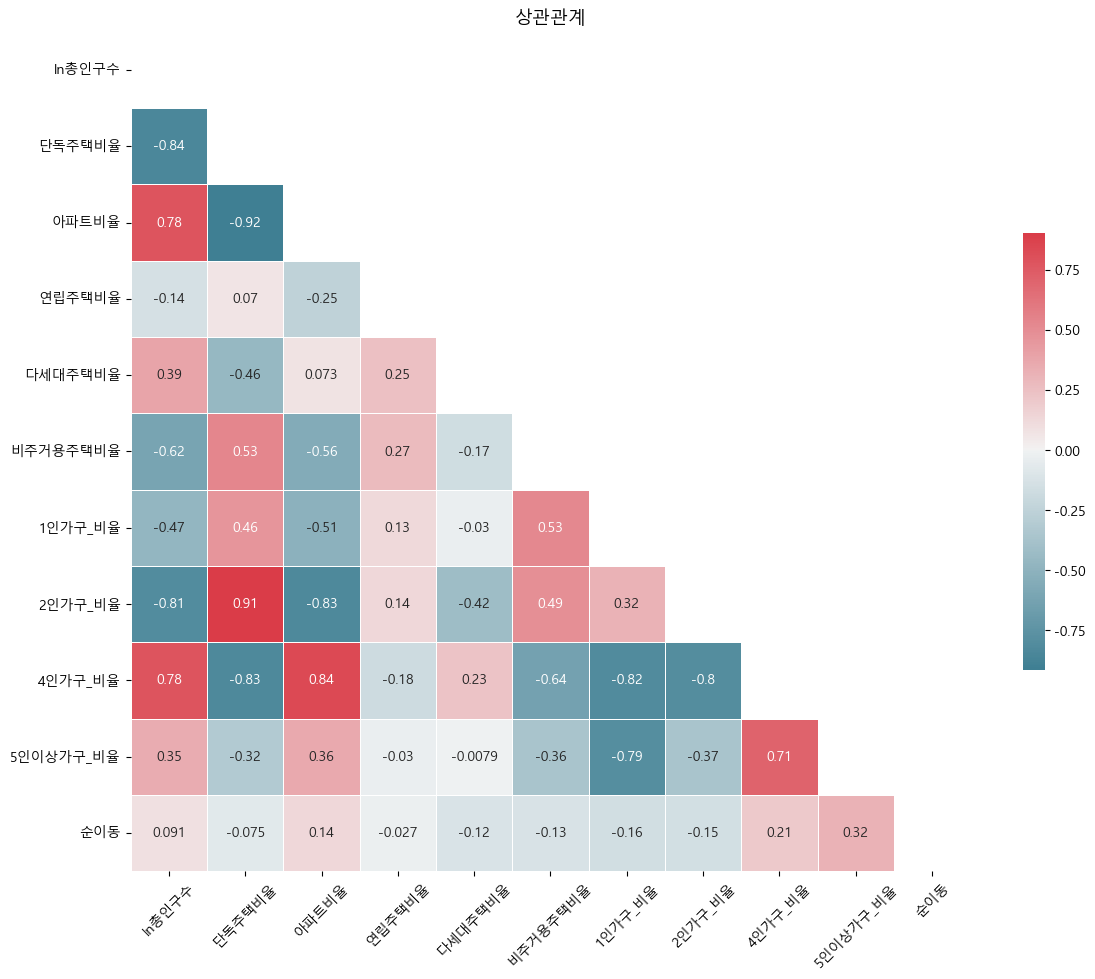

In [86]:
corr = reg_x_train.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool_)) # 하단 삼각형만 남기
f, ax = plt.subplots(figsize=(12, 10))
cmap = sns.diverging_palette(220, 10, as_cmap=True) # color 설
sns.heatmap(corr, mask=mask, cmap=cmap, center=0,square=True,annot=True, linewidths=.5, cbar_kws={"shrink": .5}) # color bar 크기 축소
plt.title('상관관계', fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()

### 표준화

In [87]:
scaler = StandardScaler()
# 훈련데이터로 변환
reg_x_train_s = scaler.fit_transform(reg_x_train)
reg_x_test_s = scaler.transform(reg_x_test)

In [88]:
# 컬럼명 유지
reg_x_train_s = pd.DataFrame(reg_x_train_s, columns = reg_x_train.columns)
reg_x_test_s = pd.DataFrame(reg_x_test_s, columns = reg_x_test.columns)

In [89]:
x_contract = sm.add_constant(reg_x_train_s)

model = sm.OLS(reg_y_train, x_contract)
ols_model = model.fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            혼합배출_후_재활용량   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     15.11
Date:                Tue, 24 Jun 2025   Prob (F-statistic):           4.45e-25
Time:                        14:43:59   Log-Likelihood:                -4846.4
No. Observations:                 460   AIC:                             9717.
Df Residuals:                     448   BIC:                             9766.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8598.2748    430.262     19.984      0.000    7752.692    9443.857
ln총인구수      5558.9796    896.169      6.203      0.000    3797.762    7320.198
단독주택비율      1.131e+06   1.81e+06      0.625      0.533   -2.43e+06    4.69e+06
아파트비율        1.04e+06   1.67e+06      0.625      0.533   -2.23e+06    4.31e+06
연립주택비율      6.878e+04    1.1e+05      0.624      0.533   -1.48e+05    2.85e+05
다세대주택비율     4.271e+05   6.87e+05      0.622      0.534   -9.22e+05    1.78e+06
비주거용주택비율    3.065e+04   4.74e+04      0.647      0.518   -6.24e+04    1.24e+05
1인가구_비율    -5664.8169   4273.530     -1.326      0.186   -1.41e+04    2733.838
2인가구_비율    -4373.5024   4307.253     -1.015      0.310   -1.28e+04    4091.428
4인가구_비율    -5522.5417   6133.230     -0.900      0.368   -1.76e+04    6530.931
5인이상가구_비율  -3101.0840   1097.959     -2.824      0.005   -5258.874    -943.294
순이동         1338.9148    477.135      2.806      0.005     401.214    2276.616
==============================================================================
Omnibus:                      387.227   Durbin-Watson:                   1.073
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11578.108
Skew:                           3.432   Prob(JB):                         0.00
Kurtosis:                      26.600   Cond. No.                     1.41e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.41e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [90]:
# Multicollinearity
# VIF
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(reg_x_train_s.values, i) for i in range(reg_x_train_s.shape[1])]
vif['features'] = reg_x_train_s.columns
vif.sort_values(by = 'VIF', ascending = False)

,VIF,features
1,1.770545e+07,단독주택비율
2,1.499281e+07,아파트비율
4,2.546976e+06,다세대주택비율
3,6.560437e+04,연립주택비율
5,1.211618e+04,비주거용주택비율
8,2.031948e+02,4인가구_비율
7,1.002155e+02,2인가구_비율
6,9.865239e+01,1인가구_비율
9,6.511883e+00,5인이상가구_비율
0,4.338248e+00,ln총인구수


In [91]:
#Feature Selection 전진 선택법

#변수 선택법
def processSubset(x,y, feature_set):
    model = sm.OLS(y,x[list(feature_set)])
    regr = model.fit()
    AIC = regr.aic
    return {"model" : regr , "AIC" : AIC}

def forward(x,y,predictors):
    remainingPredictors = [p for p in x.columns.difference(['const'])
                           if p not in predictors]
    tic=time.time()
    results=[]
    for p in remainingPredictors:
        results.append(processSubset(x=x,y=y,feature_set=predictors+[p]+
 ['const']))
    models = pd.DataFrame(results)

    bestModel = models.loc[models['AIC'].argmin()]
    toc = time.time()
    print("Processed ", models.shape[0],"models on", len(predictors)+1,
          "predictors in",(toc-tic))
    print("Selected predictors:",bestModel['model'].model.exog_names,
          'AIC : ',bestModel[0])
    return bestModel

In [92]:
#전진선택법 모델
def forward_model(x,y):
    fModels = pd.DataFrame(columns=["AIC","model"])
    tic = time.time()
    predictors = []
    for i in range(1,len(x.columns.difference(['const']))+1):
        forwardResult= forward(x,y,predictors)
        if i > 1:
            if forwardResult['AIC'] > fmodelBefore:
                break
        fModels.loc[i] = forwardResult
        predictors = fModels.loc[i]["model"].model.exog_names
        fmodelBefore = fModels.loc[i]["AIC"]
        predictors = [k for k in predictors if k != 'const']
    toc = time.time()
    print("Total elapesed time : ", (toc - tic), "seconds.")
    return (fModels['model'][len(fModels['model'])])

forwordBestModel=forward_model(x_contract, reg_y_train)
print(forwordBestModel.summary())

Processed  11 models on 1 predictors in 0.015641450881958008
Selected predictors: ['ln총인구수', 'const'] AIC :  <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x00000208FFC22990>
Processed  10 models on 2 predictors in 0.011427164077758789
Selected predictors: ['ln총인구수', '다세대주택비율', 'const'] AIC :  <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x0000020882093010>
Processed  9 models on 3 predictors in 0.013971805572509766
Selected predictors: ['ln총인구수', '다세대주택비율', '5인이상가구_비율', 'const'] AIC :  <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x0000020882038950>
Processed  8 models on 4 predictors in 0.009544849395751953
Selected predictors: ['ln총인구수', '다세대주택비율', '5인이상가구_비율', '순이동', 'const'] AIC :  <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x00000208FD129F10>
Processed  7 models on 5 predictors in 0.00937795639038086
Selected predictors: ['ln총인구수', '다세대주택비율', '5인이상가구_비율', '순이동', '1인가구_비율',

C:\Users\nammi\AppData\Local\Temp\ipykernel_15956\2638759213.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'AIC : ',bestModel[0])
C:\Users\nammi\AppData\Local\Temp\ipykernel_15956\2638759213.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'AIC : ',bestModel[0])
C:\Users\nammi\AppData\Local\Temp\ipykernel_15956\2638759213.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'AIC : ',bestModel[0])
C:\Users\nammi\AppData\Lo

In [93]:
#Feature Selection 후진 제거법
def backward(x,y,predictors):
    tic = time.time()
    results=[]
    for combo in itertools.combinations(predictors, len(predictors)-1):
        results.append(processSubset(x,y,list(combo)+['const']))
    models = pd.DataFrame(results)
    bestModel = models.loc[models['AIC'].argmin()]
    toc = time.time()
    print("Processed",models.shape[0],"models on",len(predictors)-1,
          "predictors in",(toc - tic))
    print("Selected predictors :",bestModel['model'].model.exog_names,
          ' AIC:',bestModel[0])
    return bestModel

def backword_model(x,y):
    BModels = pd.DataFrame(columns=["AIC","model"])
    tic = time.time()
    predictors = x.columns.difference(['const'])
    BmodelBefore = processSubset(x,y,predictors)['AIC']
    while(len(predictors)>1):
        backwardResult=backward(x_contract, reg_y_train, predictors)
        if backwardResult['AIC'] > BmodelBefore:
            break
        BModels.loc[len(predictors)-1] = backwardResult
        predictors = BModels.loc[len(predictors)-1]["model"].model.exog_names
        BmodelBefore = backwardResult["AIC"]
        predictors = [ k for k in predictors if k != 'const']

    toc = time.time()
    print("Total elapsed time :",(toc - tic), "seconds.")
    return (BModels["model"].dropna().iloc[0])

backwardBestModel = backword_model(x_contract, reg_y_train)
print(backwardBestModel.summary())

Processed 11 models on 10 predictors in 0.01574563980102539
Selected predictors : ['1인가구_비율', '2인가구_비율', '4인가구_비율', '5인이상가구_비율', 'ln총인구수', '단독주택비율', '비주거용주택비율', '순이동', '아파트비율', '연립주택비율', 'const']  AIC: <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x00000208FFBBEA50>
Processed 10 models on 9 predictors in 0.010509252548217773
Selected predictors : ['1인가구_비율', '2인가구_비율', '4인가구_비율', '5인이상가구_비율', 'ln총인구수', '단독주택비율', '비주거용주택비율', '순이동', '아파트비율', 'const']  AIC: <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x00000208FFC20910>
Processed 9 models on 8 predictors in 0.011200189590454102
Selected predictors : ['1인가구_비율', '2인가구_비율', '5인이상가구_비율', 'ln총인구수', '단독주택비율', '비주거용주택비율', '순이동', '아파트비율', 'const']  AIC: <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x00000208FD1849D0>
Processed 8 models on 7 predictors in 0.009995460510253906
Selected predictors : ['1인가구_비율', '5인이상가구_비율', 'ln총인구수', '단독주택비율', '비주거용주택비율', '순이동', '아파트비

C:\Users\nammi\AppData\Local\Temp\ipykernel_15956\1050713844.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ' AIC:',bestModel[0])
C:\Users\nammi\AppData\Local\Temp\ipykernel_15956\1050713844.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ' AIC:',bestModel[0])
C:\Users\nammi\AppData\Local\Temp\ipykernel_15956\1050713844.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ' AIC:',bestModel[0])
C:\Users\nammi\AppData\Local

### 전진
Selected predictors: ['ln총인구수', '다세대주택비율', '5인이상가구_비율', '순이동', '1인가구_비율', '비주거용주택비율', 'const']

In [99]:
new_reg_x_train_s = reg_x_train_s[['ln총인구수', '다세대주택비율', '5인이상가구_비율', '1인가구_비율', '비주거용주택비율', '순이동']]
new_x_contract = sm.add_constant(new_reg_x_train_s)

model2 = sm.OLS(reg_y_train, new_x_contract)
ols_model2 = model2.fit()
ols_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            혼합배출_후_재활용량   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     27.46
Date:                Tue, 24 Jun 2025   Prob (F-statistic):           5.84e-28
Time:                        14:48:52   Log-Likelihood:                -4847.7
No. Observations:                 460   AIC:                             9709.
Df Residuals:                     453   BIC:                             9738.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8598.2748    429.045     20.041      0.000    7755.110    9441.439
ln총인구수      6213.7872    608.161     10.217      0.000    5018.619    7408.955
다세대주택비율    -1366.5725    479.627     -2.849      0.005   -2309.142    -424.003
5인이상가구_비율  -2493.2250    749.094     -3.328      0.001   -3965.355   -1021.095
1인가구_비율    -1720.3376    799.545     -2.152      0.032   -3291.614    -149.061
비주거용주택비율    1112.4384    584.419      1.903      0.058     -36.070    2260.947
순이동         1284.3893    465.416      2.760      0.006     369.747    2199.032
==============================================================================
Omnibus:                      380.752   Durbin-Watson:                   1.064
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10907.258
Skew:                           3.359   Prob(JB):                         0.00
Kurtosis:                      25.890   Cond. No.                         4.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [95]:
# Multicollinearity
# VIF
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(new_reg_x_train_s.values, i) for i in range(new_reg_x_train_s.shape[1])]
vif['features'] = new_reg_x_train_s.columns
vif.sort_values(by = 'VIF', ascending = False)

,VIF,features
3,3.472807,1인가구_비율
2,3.048369,5인이상가구_비율
0,2.009245,ln총인구수
4,1.855426,비주거용주택비율
1,1.249689,다세대주택비율
5,1.176733,순이동


In [96]:
# 비주거용주택비율 0.05<pvalue
new_reg_x_train_s = reg_x_train_s[['ln총인구수', '다세대주택비율', '5인이상가구_비율', '1인가구_비율', '순이동']]
new_x_contract = sm.add_constant(new_reg_x_train_s)

model2 = sm.OLS(reg_y_train, new_x_contract)
ols_model2 = model2.fit()
ols_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            혼합배출_후_재활용량   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     32.04
Date:                Tue, 24 Jun 2025   Prob (F-statistic):           5.67e-28
Time:                        14:45:11   Log-Likelihood:                -4849.5
No. Observations:                 460   AIC:                             9711.
Df Residuals:                     454   BIC:                             9736.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8598.2748    430.282     19.983      0.000    7752.683    9443.867
ln총인구수      5678.2685    540.732     10.501      0.000    4615.620    6740.917
다세대주택비율    -1336.7565    480.754     -2.781      0.006   -2281.535    -391.978
5인이상가구_비율  -2330.5354    746.349     -3.123      0.002   -3797.262    -863.808
1인가구_비율    -1267.5611    765.545     -1.656      0.098   -2772.011     236.889
순이동         1216.2637    465.377      2.614      0.009     301.704    2130.823
==============================================================================
Omnibus:                      388.695   Durbin-Watson:                   1.049
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11662.777
Skew:                           3.451   Prob(JB):                         0.00
Kurtosis:                      26.682   Cond. No.                         3.54
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# 비주거용주택비율 포함
R-squared:	0.267 +
Adj. R-squared:	0.257 +
AIC:	9709. +
BIC:	9738.


# 비주거용주택비율 삭제
R-squared:	0.261
Adj. R-squared:	0.253
AIC:	9711.
BIC:	9736. +


-> 비주거용주택비율 포함하는 걸로 결정

In [98]:
# randomforest 해보기

In [100]:
rf_x_train = df_1[df_1['연도'] != 2023][['총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '4인가구_비율', '5인이상가구_비율','순이동']].reset_index(drop=True)
rf_y_train = df_1[df_1['연도'] != 2023][['혼합배출_후_재활용량']].reset_index(drop=True)

rf_x_test = df_1[df_1['연도'] == 2023][['총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '4인가구_비율', '5인이상가구_비율', '순이동']].reset_index(drop=True)
rf_y_test = df_1[df_1['연도'] == 2023][['혼합배출_후_재활용량']].reset_index(drop=True)

In [101]:
randomforest_reg = RandomForestRegressor(random_state=42)
randomforest_reg.fit(reg_x_train_s, reg_y_train)
randomforest_raw = RandomForestRegressor(random_state=42)
randomforest_raw.fit(rf_x_train, rf_y_train)

c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [102]:
predictions_reg = randomforest_reg.predict(reg_x_test_s)
mse = mean_squared_error(reg_y_test, predictions_reg)
rmse = np.sqrt(mse)
r2 = r2_score(reg_y_test, predictions_reg)
mae = mean_absolute_error(reg_y_test, predictions_reg)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

predictions_raw = randomforest_raw.predict(rf_x_test)
mse = mean_squared_error(rf_y_test, predictions_raw)
rmse = np.sqrt(mse)
r2 = r2_score(rf_y_test, predictions_raw)
mae = mean_absolute_error(rf_y_test, predictions_raw)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 166414907.6379, RMSE: 12900.1902, R^2: 0.3923, MAE: 6575.3593
MSE: 166284060.2290, RMSE: 12895.1177, R^2: 0.3928, MAE: 6573.8859


In [103]:
# 이친구도 raw 데이터가 좋음

In [104]:
# 회귀에서 선택한 데이터로 randomforest 진행해보기

In [105]:
final_x_train = rf_x_train[['총인구수', '다세대주택비율', '5인이상가구_비율', '1인가구_비율', '비주거용주택비율', '순이동']]
final_x_test = rf_x_test[['총인구수', '다세대주택비율', '5인이상가구_비율', '1인가구_비율', '비주거용주택비율', '순이동']]

In [106]:
final_model = RandomForestRegressor(random_state=42)
final_model.fit(final_x_train, rf_y_train)

c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [107]:
from sklearn.model_selection import cross_val_score

# 튜닝된 모델이 있다면 튜닝된 모델을 사용, 없다면 기본 모델 사용
# model_to_evaluate = model_rf # 튜닝 전
model_to_evaluate = final_model # 튜닝 후

# 5-겹 교차 검증으로 R^2 스코어 계산
# 이때도 OLS에서 선택된 변수들로 구성된 스케일링된 x_train을 사용합니다.
scores = cross_val_score(model_to_evaluate, rf_x_train, rf_y_train, cv=5, scoring='r2', n_jobs=-1)

print(f"\nCross-validation R^2 scores: {scores}")
print(f"Mean R^2: {scores.mean():.4f}")
print(f"Standard deviation of R^2: {scores.std():.4f}")

# RMSE도 확인하고 싶다면 scoring을 'neg_mean_squared_error'로 변경 후 sqrt 적용
rmse_scores = np.sqrt(-cross_val_score(model_to_evaluate, rf_x_train, rf_y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
print(f"Cross-validation RMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.4f}")
print(f"Standard deviation of RMSE: {rmse_scores.std():.4f}")


Cross-validation R^2 scores: [-0.74411685  0.16257923 -0.03492088 -3.20795928  0.11001209]
Mean R^2: -0.7429
Standard deviation of R^2: 1.2748
Cross-validation RMSE scores: [11669.15319128 15776.88458426  8397.26390589 13494.38978978
  5940.19237257]
Mean RMSE: 11055.5768
Standard deviation of RMSE: 3517.0675


In [108]:
predictions = final_model.predict(final_x_test)
mse = mean_squared_error(rf_y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(rf_y_test, predictions)
mae = mean_absolute_error(rf_y_test, predictions)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 167652370.7063, RMSE: 12948.0644, R^2: 0.3878, MAE: 7040.5893


In [109]:
# 부산 예측하기

In [112]:
x_busan = busan_2023[['행정구역','연도','총인구수', '다세대주택비율', '5인이상가구_비율', '1인가구_비율', '비주거용주택비율', '순이동']].set_index(['행정구역','연도'])
x_busan

,,총인구수,다세대주택비율,5인이상가구_비율,1인가구_비율,비주거용주택비율,순이동
행정구역,연도,,,,,,
부산_강서구,2023,142396,0.0159,0.042828,0.305750,0.0090,-1203
부산_금정구,2023,215590,0.2080,0.025210,0.400460,0.0144,-4379
부산_기장군,2023,178729,0.0554,0.039808,0.308858,0.0101,450
부산_남구,2023,254185,0.2068,0.029717,0.359557,0.0082,-998
부산_동구,2023,87792,0.1270,0.022260,0.435892,0.0149,1932
부산_동래구,2023,270815,0.1366,0.032435,0.312375,0.0119,-1603
부산_부산진구,2023,359508,0.1410,0.024514,0.416489,0.0084,4821
부산_북구,2023,273596,0.0882,0.030432,0.316077,0.0061,-4464
부산_사상구,2023,202932,0.1050,0.026425,0.386925,0.0106,142


In [113]:
predicted_busan = final_model.predict(x_busan)

In [114]:
predicted_y = busan_2023[['행정구역','연도','총인구수','혼합배출_후_재활용량']]

In [115]:
predicted_y['새로운_발생량'] = predicted_busan

C:\Users\nammi\AppData\Local\Temp\ipykernel_15956\3122906572.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_y['새로운_발생량'] = predicted_busan


In [117]:
predicted_y['오차(실제값기준)'] = predicted_y['혼합배출_후_재활용량'] - predicted_y['새로운_발생량']

C:\Users\nammi\AppData\Local\Temp\ipykernel_15956\4152376718.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_y['오차(실제값기준)'] = predicted_y['혼합배출_후_재활용량'] - predicted_y['새로운_발생량']


C:\Users\nammi\AppData\Local\Temp\ipykernel_15956\4256542396.py:13: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  plt.tight_layout()


c:\workspace\busan\.venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
c:\workspace\busan\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


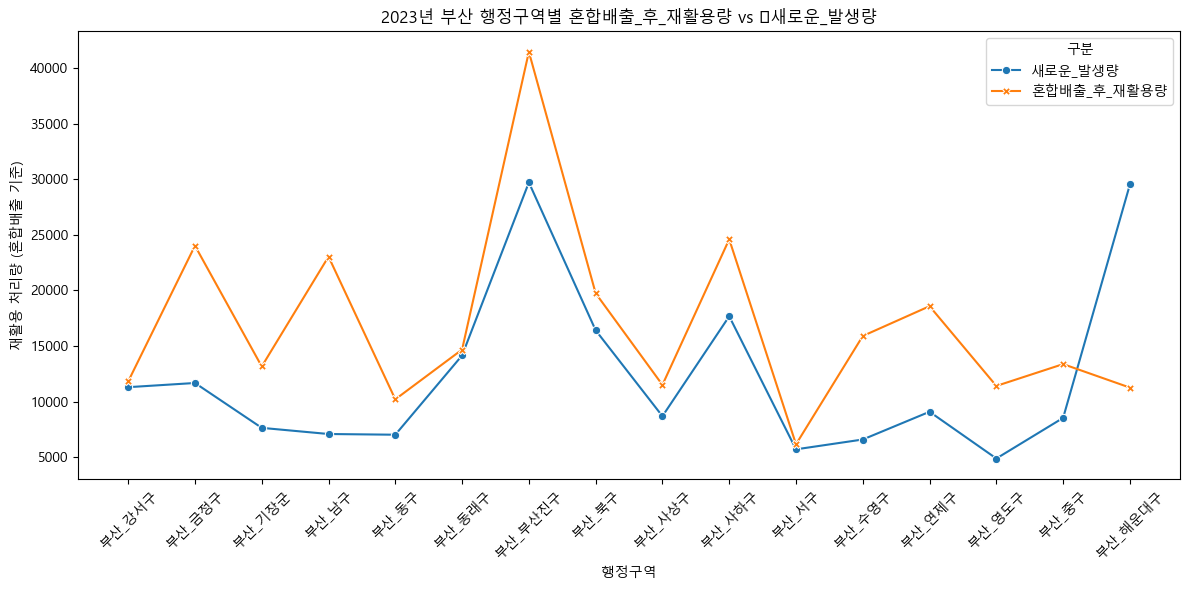

In [119]:
# 시군구별 예측값/실제값 형태 변환
df_plot = predicted_y[['행정구역', '새로운_발생량', '혼합배출_후_재활용량']].melt(id_vars='행정구역', var_name='구분', value_name='값')

# 시군구 이름 기준 정렬
order = predicted_y.sort_values(by='혼합배출_후_재활용량', ascending=False)['행정구역']

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='행정구역', y='값', hue='구분', style='구분', markers=True, dashes=False, sort=False)
plt.xticks(rotation=45)
plt.title('2023년 부산 행정구역별 혼합배출_후_재활용량 vs 	새로운_발생량')
plt.ylabel('재활용 처리량 (혼합배출 기준)')
plt.xlabel('행정구역')
plt.tight_layout()
plt.legend(title='구분')

C:\Users\nammi\AppData\Local\Temp\ipykernel_15956\830023757.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted_heatmap, x='행정구역', y='오차(실제값기준)', palette='summer')


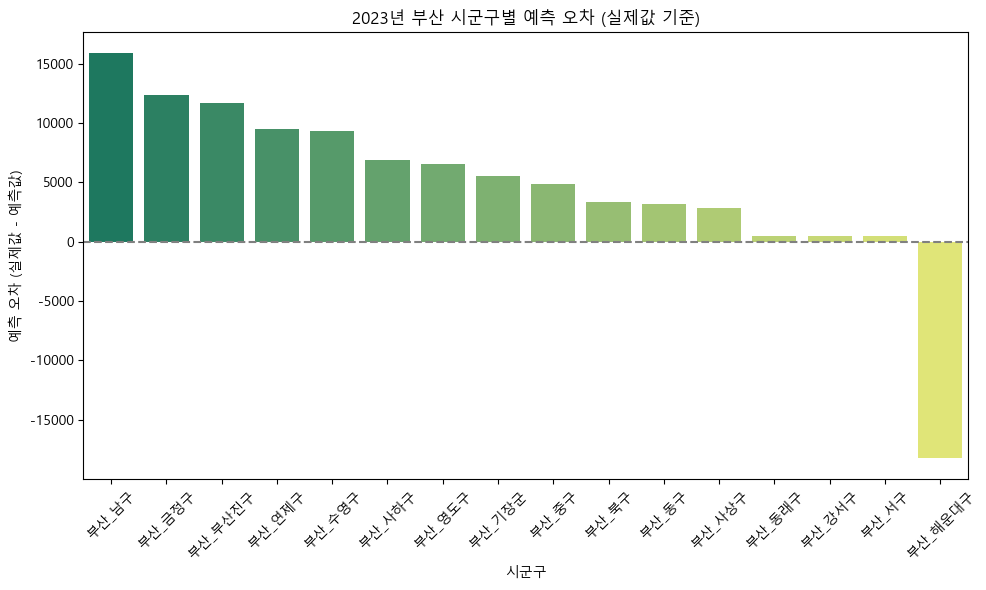

In [120]:

plt.figure(figsize=(10, 6))
df_sorted_heatmap = predicted_y.sort_values(by='오차(실제값기준)', ascending=False)
sns.barplot(data=df_sorted_heatmap, x='행정구역', y='오차(실제값기준)', palette='summer')
plt.xticks(rotation=45)
plt.title('2023년 부산 시군구별 예측 오차 (실제값 기준)')
plt.ylabel('예측 오차 (실제값 - 예측값)')
plt.xlabel('시군구')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()

In [123]:
# 원래는 예측값의 정답은 없지만 확인해보기
mse = mean_squared_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)
rmse = np.sqrt(mse)
r2 = r2_score(predicted_y['혼합배출_후_재활용량'], predicted_busan)
mae = mean_absolute_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 76829053.8112, RMSE: 8765.2184, R^2: -0.1480, MAE: 6982.7985
